In [16]:
import pandas as pd
df = pd.read_csv('최종전처리.csv', encoding='cp949')
df

,Unnamed: 0,시도,일시,fire,평균기온(°C),최고기온(°C),일강수량(mm),평균 상대습도(%),최대 풍속(m/s),평균 풍속(m/s),최저기온(°C),일 최심적설(cm),실효습도,년도,논_비율,밭_비율,도시_산림_인접지수
0,0,경북,2016-01-03,1,4.376923,16.3,0.0,72.415385,6.5,1.184615,-6.6,0.0,59.201499,2016,14.049405,19.069746,10.158780
1,1,경북,2016-01-04,0,5.192308,12.9,0.0,50.807692,8.3,2.715385,-6.2,0.0,55.198808,2016,14.049405,19.069746,10.158780
2,2,경북,2016-01-05,0,0.423077,7.0,0.0,33.076923,8.1,2.646154,-7.0,0.0,46.443746,2016,14.049405,19.069746,10.158780
3,3,경북,2016-01-06,1,0.084615,7.0,0.0,46.515385,9.6,2.976923,-9.8,0.0,43.977776,2016,14.049405,19.069746,10.158780
4,4,경북,2016-01-07,0,-0.030769,6.4,0.0,44.192308,8.1,3.092308,-9.2,0.0,41.731961,2016,14.049405,19.069746,10.158780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62013,63262,제주,2025-12-27,0,4.200000,9.4,0.0,59.325000,6.1,2.625000,-2.8,0.0,54.115659,2025,0.001604,7.444119,6.744372
62014,63263,제주,2025-12-28,0,8.950000,13.7,0.0,53.875000,12.7,2.800000,1.0,0.0,51.877249,2025,0.001604,7.444119,6.744372
62015,63264,제주,2025-12-29,0,12.325000,17.3,0.0,60.600000,11.5,4.400000,5.0,0.0,52.197272,2025,0.001604,7.444119,6.744372
62016,63265,제주,2025-12-30,0,8.325000,15.8,0.0,51.725000,10.3,3.700000,3.6,0.0,49.414664,2025,0.001604,7.444119,6.744372


scale_pos_weight: 11.18418467583497
0.9684967952594026
0.9104321186713963

TEST PERFORMANCE
Accuracy: 0.9104
Recall: 0.6562
F1 Score: 0.5460
ROC-AUC: 0.9077

              precision    recall  f1-score   support

           0       0.97      0.93      0.95     11386
           1       0.47      0.66      0.55      1018

    accuracy                           0.91     12404
   macro avg       0.72      0.79      0.75     12404
weighted avg       0.93      0.91      0.92     12404



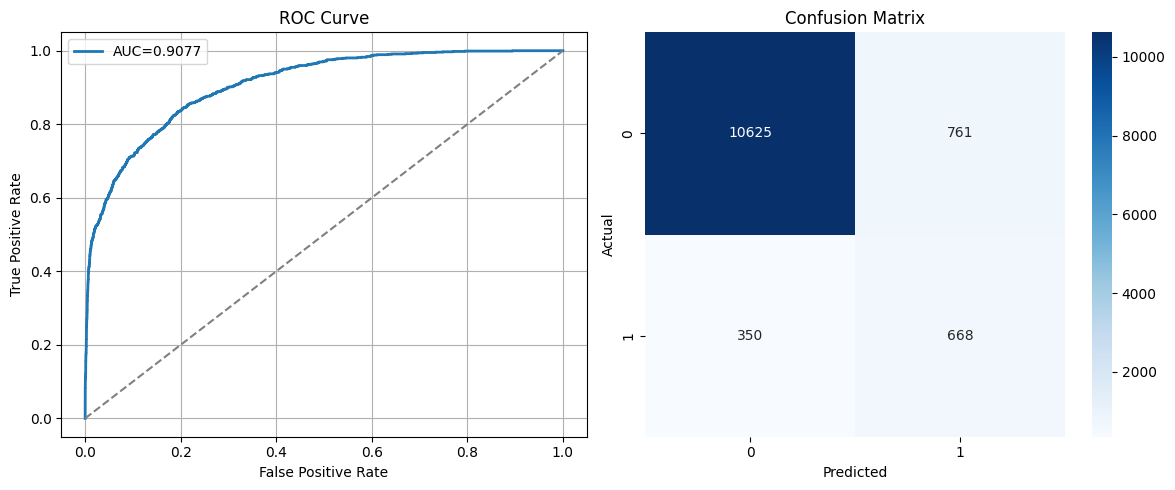

In [17]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, recall_score, f1_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score,roc_curve,confusion_matrix,precision_score
import seaborn as sns

df = df.drop(['시도','일시','년도','최고기온(°C)', '최저기온(°C)'], axis=1)
X = df.drop('fire', axis=1).to_numpy()
y = df['fire'].to_numpy()

# Train/Test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.2, stratify=y
)

# 불균형 비율 계산
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale}")

# 최적 파라미터로 모델 학습
best_model = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=1.0,
    scale_pos_weight=scale,
    random_state=0
)

best_model.fit(X_train, y_train)
print(best_model.score(X_train,y_train))
print(best_model.score(X_test,y_test))
# 예측
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# 성능 출력
print("\n" + "="*50)
print("TEST PERFORMANCE")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_test):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_test):.4f}")
print("\n" + classification_report(y_test, y_pred_test))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
auc = roc_auc_score(y_test, y_proba_test)

axes[0].plot(fpr, tpr, label=f"AUC={auc:.4f}", linewidth=2)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()
axes[0].grid(True)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, recall_score, f1_score
from xgboost import XGBClassifier

df = df.drop(['시도','일시','년도','최고기온(°C)', '최저기온(°C)'],axis=1)
X = df.drop('fire',axis=1).to_numpy()
y = df['fire'].to_numpy()

# SMOTE 부분 삭제하고 바로 시작
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42,test_size=0.2,stratify=y)

# 불균형 비율 계산
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale}")

xgb_clf = XGBClassifier(
    scale_pos_weight=scale,  # ✅ 이게 핵심
    random_state=0
)

# params = {
#     "n_estimators": [100, 300, 500],
#     "max_depth": [3, 5, 7],  # 11은 너무 깊음
#     "learning_rate": [0.01, 0.05, 0.1],
#     "subsample": [0.7, 0.8, 1.0],  # 과적합 방지
#     "colsample_bytree": [0.7, 0.8, 1.0],  # 과적합 방지
# }

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# grid_search = GridSearchCV(
#     xgb_clf,
#     params,
#     cv=cv,
#     scoring="f1",
#     n_jobs=-1,
#     verbose=1
# )

# # ✅ 원본 train 데이터로 학습
# grid_search.fit(X_train, y_train)

# print(grid_search.best_params_)
# print(grid_search.best_score_)

# best_model = grid_search.best_estimator_
# y_pred_best = best_model.predict(X_test)
# print("Test F1:", f1_score(y_test, y_pred_best))
# print("Test recall:", recall_score(y_test, y_pred_best))

scale_pos_weight: 11.18418467583497
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 500, 'subsample': 0.8}
0.5413718099610404
Test F1: 0.5459746628524724
Test recall: 0.656188605108055


0.8164441614334021
0.8248951950983554
0.8248951950983554
0.8045186640471512
0.42992125984251967
              precision    recall  f1-score   support

           0       0.98      0.83      0.90     11386
           1       0.29      0.80      0.43      1018

    accuracy                           0.82     12404
   macro avg       0.64      0.82      0.66     12404
weighted avg       0.92      0.82      0.86     12404

ROC-AUC: 0.9045546145147059


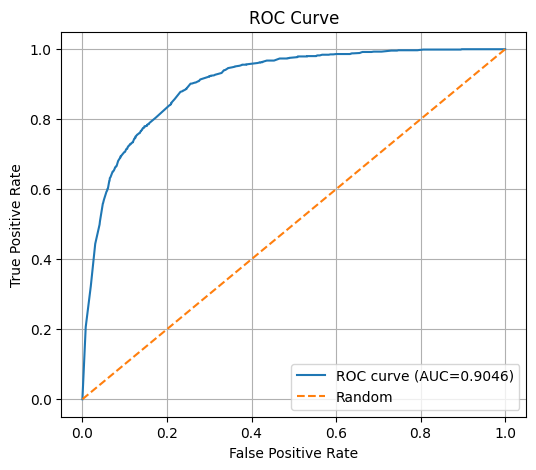

Fitting 5 folds for each of 100 candidates, totalling 500 fits
{'learning_rate': 0.1, 'max_depth': 11, 'n_estimators': 1000}
0.9480526296866651
Best model test F1: 0.553594489883771
Best model test recall: 0.6316306483300589
              precision    recall  f1-score   support

           0       0.97      0.94      0.95     11386
           1       0.49      0.63      0.55      1018

    accuracy                           0.92     12404
   macro avg       0.73      0.79      0.75     12404
weighted avg       0.93      0.92      0.92     12404



In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

sc = StandardScaler()
df = df.drop(['시도','일시','년도','최고기온(°C)', '최저기온(°C)'],axis=1)
X = df.drop('fire',axis=1).to_numpy()
y = df['fire'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42,test_size=0.2,stratify=y)
# X_train_sc = sc.fit_transform(X_train)
# X_test_sc = sc.transform(X_test)

smote = SMOTE(random_state=42)
X_resample, y_resample = smote.fit_resample(X_train,y_train)

from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=10,
    max_depth=3,
    learning_rate=0.1,
    random_state=0
)

xgb_clf.fit(X_resample,y_resample)

print(xgb_clf.score(X_resample,y_resample))
print(xgb_clf.score(X_test,y_test))

from sklearn.metrics import accuracy_score, classification_report, recall_score, f1_score

y_pred_train = xgb_clf.predict(X_train)
y_pred_test = xgb_clf.predict(X_test)

print(accuracy_score(y_test, y_pred_test))
print(recall_score(y_test, y_pred_test))

print(f1_score(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1) 양성(클래스=1) 확률 예측
y_score_test = xgb_clf.predict_proba(X_test)[:, 1]

# 2) AUC 계산
auc = roc_auc_score(y_test, y_score_test)
print("ROC-AUC:", auc)

# 3) ROC Curve 좌표 계산
fpr, tpr, thresholds = roc_curve(y_test, y_score_test, pos_label=1)

# 4) ROC Curve 그리기
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC={auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

from sklearn.model_selection import GridSearchCV, StratifiedKFold

params = {
    "n_estimators": [100, 300, 500, 700, 1000],
    "max_depth": [3, 5, 7, 9, 11],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    xgb_clf,
    params,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

# ✅ 수정: SMOTE 적용된 데이터로 GridSearch
grid_search.fit(X_resample, y_resample)

print(grid_search.best_params_)
print(grid_search.best_score_)

# 최적 모델로 테스트 평가
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print("Best model test F1:", f1_score(y_test, y_pred_best))
print("Best model test recall:", recall_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

In [9]:
df = df.drop(['Unnamed: 0'],axis=1)

In [10]:
df['일시'] = pd.to_datetime(df['일시'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62018 entries, 0 to 62017
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   시도          62018 non-null  object        
 1   일시          62018 non-null  datetime64[ns]
 2   fire        62018 non-null  int64         
 3   평균기온(°C)    62018 non-null  float64       
 4   최고기온(°C)    62018 non-null  float64       
 5   일강수량(mm)    62018 non-null  float64       
 6   평균 상대습도(%)  62018 non-null  float64       
 7   최대 풍속(m/s)  62018 non-null  float64       
 8   평균 풍속(m/s)  62018 non-null  float64       
 9   최저기온(°C)    62018 non-null  float64       
 10  일 최심적설(cm)  62018 non-null  float64       
 11  실효습도        62018 non-null  float64       
 12  년도          62018 non-null  int64         
 13  논_비율        62018 non-null  float64       
 14  밭_비율        62018 non-null  float64       
 15  도시_산림_인접지수  62018 non-null  float64       
dtypes: datetime64[ns](1), 

In [11]:
print(df.isnull().sum())

시도            0
일시            0
fire          0
평균기온(°C)      0
최고기온(°C)      0
일강수량(mm)      0
평균 상대습도(%)    0
최대 풍속(m/s)    0
평균 풍속(m/s)    0
최저기온(°C)      0
일 최심적설(cm)    0
실효습도          0
년도            0
논_비율          0
밭_비율          0
도시_산림_인접지수    0
dtype: int64


In [12]:
# smote하지 않은 것
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

xgb_clf = XGBClassifier()
df = df.drop(['시도','일시','년도','최고기온(°C)', '최저기온(°C)'],axis=1)
X = df.drop('fire',axis=1).to_numpy()
y = df['fire'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)

# 1) 전체 -> train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2) train -> tr/eval
X_tr, X_eval, y_tr, y_eval = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# 3) 스케일링: tr로만 fit
scaler = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_tr)
X_eval_sc = scaler.transform(X_eval)
X_test_sc = scaler.transform(X_test)




In [13]:
# 4) SMOTE: tr에만
smote = SMOTE(random_state=42)
X_tr_res, y_tr_res = smote.fit_resample(X_tr_sc, y_tr)

# 5) XGBoost 학습 + early stopping (eval은 원본)
xgb_clf.fit(
    X_tr_res, y_tr_res,
    eval_set=[(X_eval_sc, y_eval)],
    verbose=100,
)

# 6) 최종 평가는 test로만
y_pred_test = xgb_clf.predict(X_test_sc)

[0]	validation_0-logloss:0.56425
[99]	validation_0-logloss:0.22885


In [ ]:
print(xgb_clf.score(X_tr_sc,y_resample))
print(xgb_clf.score(X_test_sc,y_test))

NameError: name 'X_train_sc' is not defined

<Figure size 640x480 with 0 Axes>

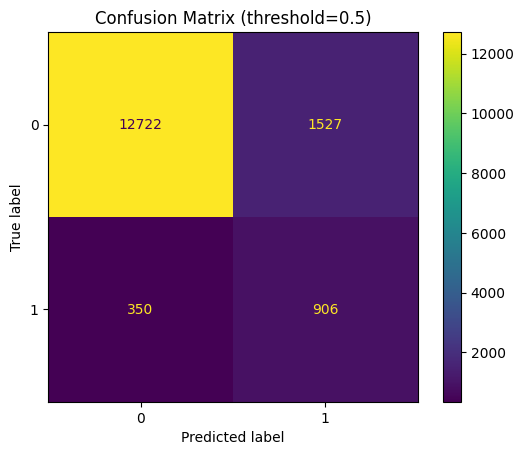

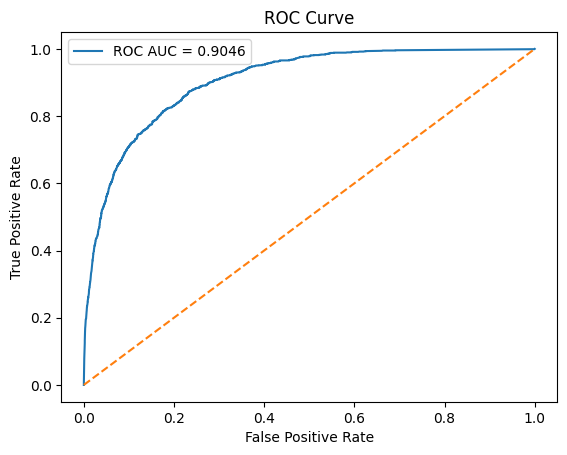

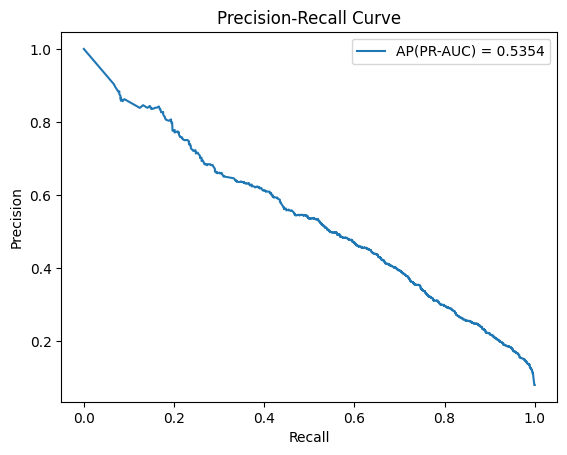

C:\Users\parks\AppData\Local\Temp\ipykernel_9704\3259587371.py:67: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\parks\AppData\Local\Temp\ipykernel_9704\3259587371.py:67: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\parks\AppData\Local\Temp\ipykernel_9704\3259587371.py:67: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\parks\AppData\Local\Temp\ipykernel_9704\3259587371.py:67: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\parks\AppData\Local\Temp\ipykernel_9704\3259587371.py:67: UserWarning: Glyph 45436 (\N{HANGUL SYLLABLE NON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\parks\AppData\Local\Temp\ipykernel_9704\3259587371.py:67: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(

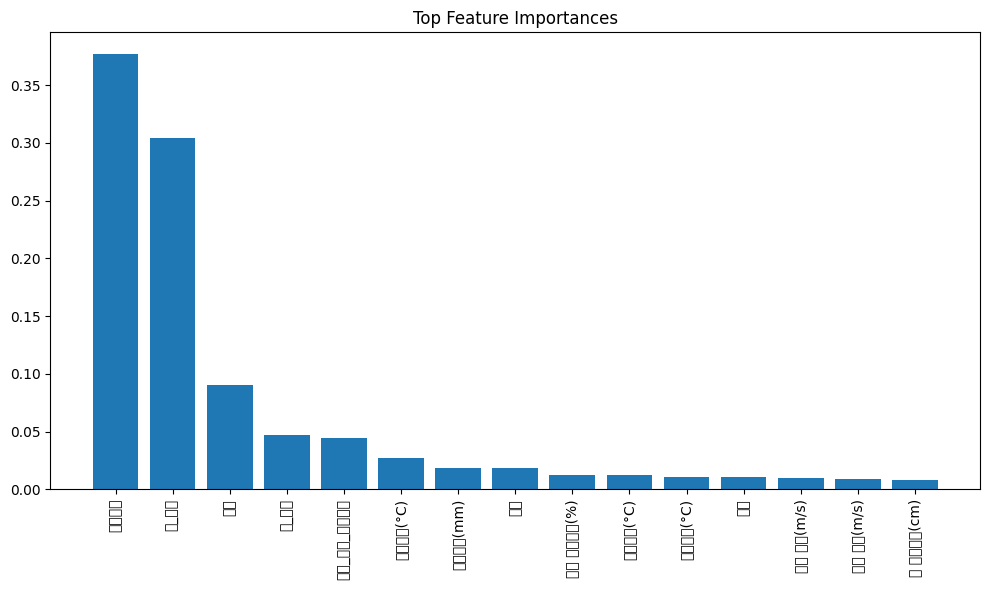

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# 1) 예측 확률/라벨
y_proba = xgb_clf.predict_proba(X_test_sc)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

# -----------------------
# (A) Confusion Matrix
# -----------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure()
disp.plot(values_format='d')
plt.title("Confusion Matrix (threshold=0.5)")
plt.show()

# -----------------------
# (B) ROC Curve
# -----------------------
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# -----------------------
# (C) Precision-Recall Curve
# -----------------------
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure()
plt.plot(recall, precision, label=f"AP(PR-AUC) = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# -----------------------
# (D) Feature Importance (XGBoost)
# -----------------------
# to_numpy()로 학습하면 컬럼명이 날아가서, df에서 컬럼명을 따로 가져와야 해요.
feature_names = df.drop(columns=['fire']).columns.tolist()

importances = xgb_clf.feature_importances_
idx = np.argsort(importances)[::-1]

top_k = min(20, len(feature_names))
plt.figure(figsize=(10, 6))
plt.bar(range(top_k), importances[idx][:top_k])
plt.xticks(range(top_k), [feature_names[i] for i in idx[:top_k]], rotation=90)
plt.title("Top Feature Importances")
plt.tight_layout()
plt.show()
